Haroon Mehmood DH-3885

Task 1: Iris Dataset Exploration & Visualization

Objective: Understand how to read, summarize, and visualize a dataset.

Shape: (150, 5)
Columns: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


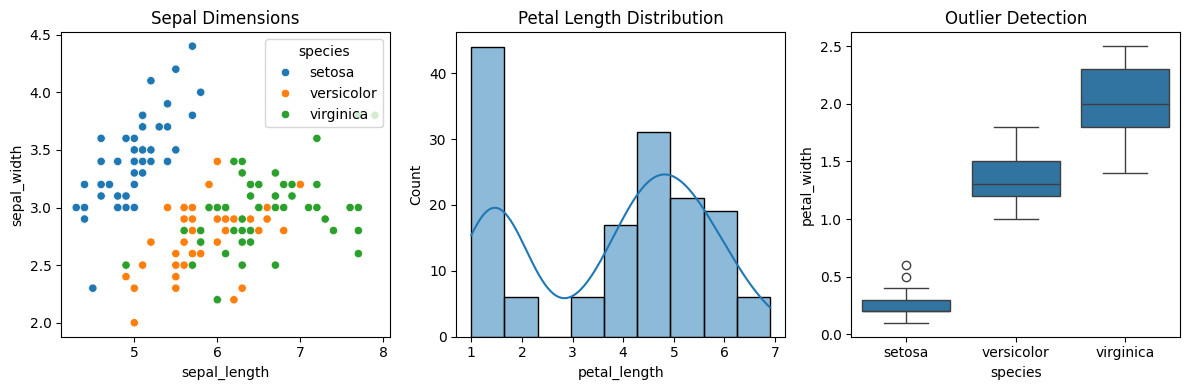

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset 
iris = sns.load_dataset('iris')

# Display structure 
print(f"Shape: {iris.shape}")
print(f"Columns: {iris.columns}")
print(iris.head())

# Visualizations 
plt.figure(figsize=(12, 4))

# Scatter plot
plt.subplot(1, 3, 1)
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Dimensions')

# Histogram 
plt.subplot(1, 3, 2)
sns.histplot(iris['petal_length'], kde=True)
plt.title('Petal Length Distribution')

# Box plot 
plt.subplot(1, 3, 3)
sns.boxplot(x='species', y='petal_width', data=iris)
plt.title('Outlier Detection')

plt.tight_layout()
plt.show()

Task 2: Credit Risk Prediction

Objective: Predict loan applicant defaults using the Loan Prediction Dataset

/var/folders/9l/hzmrmn4s5ws7jykw19r6zv3h0000gn/T/ipykernel_13613/2713510425.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/var/folders/9l/hzmrmn4s5ws7jykw19r6zv3h0000gn/T/ipykernel_13613/2713510425.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

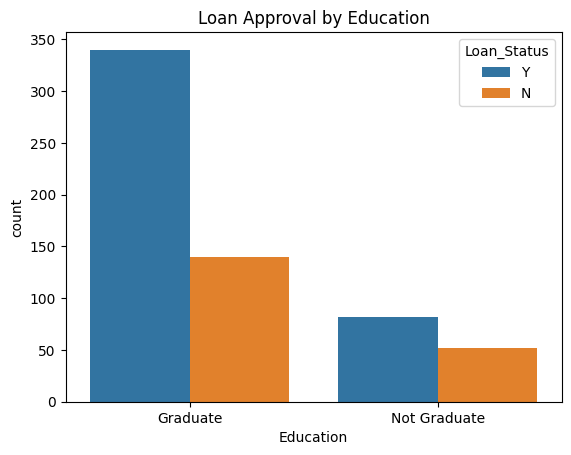

Validation Accuracy: 0.7886178861788617


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load the local files
train_df = pd.read_csv('/Users/subhanmahmood/Documents/loan prediction data set/train.csv')
test_df = pd.read_csv('/Users/subhanmahmood/Documents/loan prediction data set/test.csv')

# 2. Handle Missing Data (Requirement for Task 2) 
# Filling categorical with mode and numerical with median
for df in [train_df, test_df]:
    df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
    df['Married'].fillna(df['Married'].mode()[0], inplace=True)
    df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
    df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
    df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
    df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
    df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# 3. Exploratory Data Analysis (EDA) 
sns.countplot(x='Education', hue='Loan_Status', data=train_df)
plt.title('Loan Approval by Education')
plt.show()

# 4. Prepare Data for Training 
# Convert 'Loan_Status' to 1 (Y) and 0 (N)
train_df['Loan_Status'] = train_df['Loan_Status'].map({'Y': 1, 'N': 0})

# Simple feature selection (You can add more)
X = train_df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']]
y = train_df['Loan_Status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train and Evaluate [cite: 34, 35, 40]
model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, predictions)}")

Task 3: Customer Churn Prediction (Bank)

Objective: Identify customers likely to leave the bank.

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset from your local path
file_path = '/Users/subhanmahmood/Documents/Churn_Modelling.csv'
df = pd.read_csv(file_path)

# 2. Clean and prepare the dataset [cite: 46]
# Drop irrelevant columns (RowNumber, CustomerId, Surname)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 3. Encode categorical features (Geography and Gender) [cite: 47, 51]
le = LabelEncoder()
df_clean['Geography'] = le.fit_transform(df_clean['Geography'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# 4. Split data into features (X) and target (y)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train a classification model [cite: 48]
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 6. Analyze feature importance [cite: 49, 52]
importances = clf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print("Feature Importance:")
print(feature_importance_df.sort_values(by='Importance', ascending=False))

# 7. Evaluate performance [cite: 52]
y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Feature Importance:
           Feature  Importance
3              Age    0.240453
9  EstimatedSalary    0.148004
0      CreditScore    0.142369
5          Balance    0.138670
6    NumOfProducts    0.132061
4           Tenure    0.080932
8   IsActiveMember    0.042807
1        Geography    0.037402
2           Gender    0.019032
7        HasCrCard    0.018269

Accuracy: 0.8645

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



Task 4: Predicting Insurance Claim Amounts

Objective: Estimate medical insurance charges using Linear Regression.


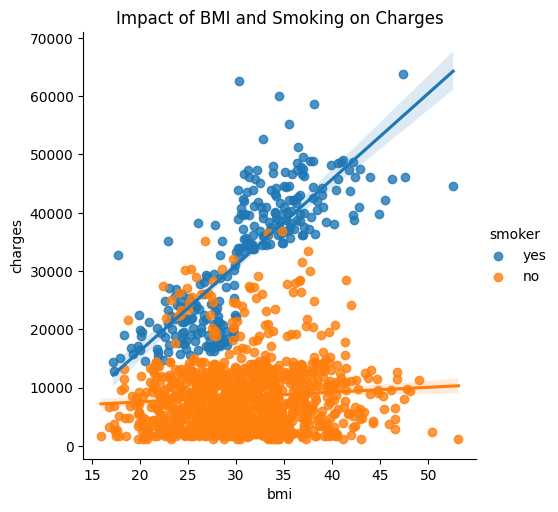

MAE: 4181.194473753645
RMSE: 5796.284659276271

Feature Impact:
                   Coefficient
smoker            23651.128856
children            425.278784
bmi                 337.092552
age                 256.975706
sex                  18.591692
region_northwest   -370.677326
region_southeast   -657.864297
region_southwest   -809.799354


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the dataset
file_path = '/Users/subhanmahmood/Downloads/insurance.csv'
df = pd.read_csv(file_path)

# 2. Prepare Data (Encoding is necessary for Linear Regression) [cite: 60, 61]
# Convert categorical strings to numbers
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 1, 'male': 0})
# Use dummy variables for 'region'
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# 3. Define Features and Target
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Regression Model 
reg = LinearRegression()
reg.fit(X_train, y_train)

# 5. Visualize impacts 
# Note: Use the original 'df' or a copy for visualization to keep categorical labels
sns.lmplot(x='bmi', y='charges', hue='smoker', data=pd.read_csv(file_path))
plt.title('Impact of BMI and Smoking on Charges')
plt.show()

# 6. Evaluate Performance 
preds = reg.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds))}")

# 7. Coefficient Analysis (Optional insight for your GitHub README)
coeff_df = pd.DataFrame(reg.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Impact:")
print(coeff_df.sort_values(by='Coefficient', ascending=False))

Task 5: Personal Loan Acceptance Prediction

Objective: Predict which customers will accept a personal loan offer.

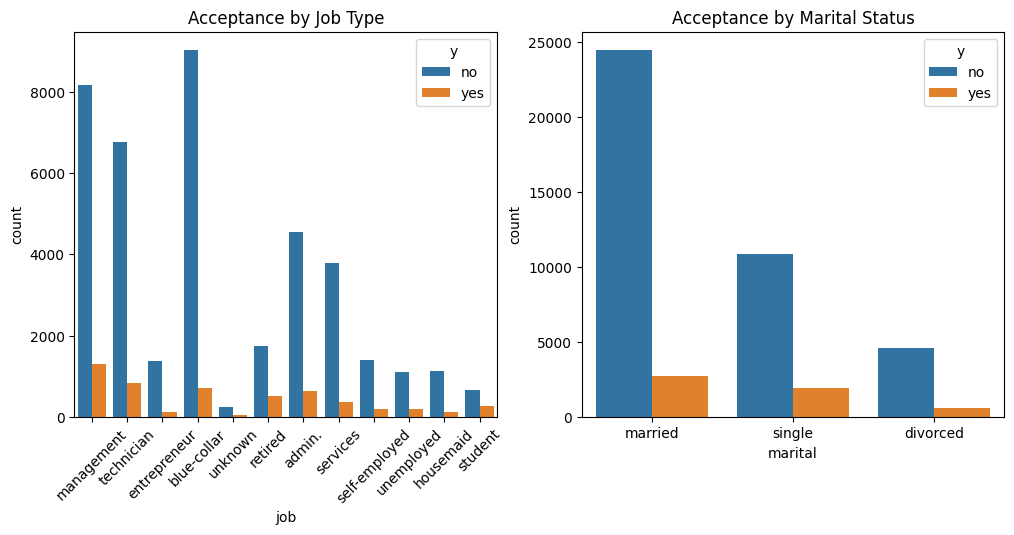

Accuracy: 0.8935087913303107

Confusion Matrix:
[[7644  308]
 [ 655  436]]

Key Influencing Factors:
duration    0.578134
poutcome    0.144215
month       0.113463
age         0.065036
pdays       0.057855
dtype: float64


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset with proper column names
# (Based on standard UCI Bank Marketing Dataset structure)
column_names = [
    'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 
    'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 
    'previous', 'poutcome', 'y'
]

# Note: Using your local path and specifying semicolon if needed
# The UCI version often uses ';' as a delimiter
file_path = '/Users/subhanmahmood/Downloads/bank-full.csv'
df = pd.read_csv(file_path, names=column_names, sep=None, engine='python')

# 2. Data Exploration (EDA) [cite: 175, 179]
plt.figure(figsize=(12, 5))

# Job vs Acceptance
plt.subplot(1, 2, 1)
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Acceptance by Job Type')

# Marital Status vs Acceptance
plt.subplot(1, 2, 2)
sns.countplot(x='marital', hue='y', data=df)
plt.title('Acceptance by Marital Status')
plt.show()

# 3. Data Cleaning and Preparation [cite: 180]
# Convert target 'y' (yes/no) to binary (1/0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Encode categorical variables for the model
le = LabelEncoder()
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 4. Model Training (Decision Tree) [cite: 176, 180]
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

# 5. Evaluate and Extract Insights [cite: 177, 181]
y_pred = dtree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Identify important features for business insight
importances = pd.Series(dtree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nKey Influencing Factors:")
print(importances.head(5))